# Predictive Modelling

This notebook applies machine learning to help us identify regions on the seafloor with mineralization. By using a Random Forest model trained on known geological and geophysical data, we explore what drives mineralization and where deposits may be hiding. The key components of this analysis include:

- Training a model on geological data to predict mineral deposit locations.

- Identifying which features are most important in finding these deposits.

- Quantifying uncertainty to show where the model is more or less confident, allowing users to interpret the accuracy of the model.

- Mapping the predictions over geological time, through an interactive map, to support exploration efforts.

We begin by importing the required libraries:

In [2]:
# =============================================================================
# IMPORT LIBRARIES AND DEPENDENCIES
# =============================================================================

from ipywidgets import interact

import cartopy.crs as ccrs
import dask.dataframe as dd
from dask_ml.wrappers import ParallelPostFit
import joblib
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import shap
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, brier_score_loss, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from tqdm import tqdm

# Custom analysis modules
# NOTE: Ensure the 'lib/' folder is downloaded and in the same directory!
from lib.main import *
from lib.plot import *

# Load configuration parameters (e.g. paths, model names)
from parameters import parameters

ModuleNotFoundError: No module named 'ipywidgets'

### Setup

This section of code loads analysis parameters (from `'parameters.py'`) and sets up file paths for data storage.

`NOTE`: You can change the analysis settings (like time range, resolution, and file locations) in `parameters.py`, which is in the same folder as this notebook. It's structured as a dictionary; look for entries like 'plate_model_name', 'timespan', and 'grid_resolution' to adjust values as needed.

In [ ]:
# Plate model name
plate_model_name = parameters["plate_model_name"]

# Timespan for analysis
temporal_resolution = parameters["temporal_resolution"]
time_min = parameters["timespan"]["min"]
time_max = parameters["timespan"]["max"]
time_steps = range(time_min, time_max + temporal_resolution, temporal_resolution)

columns_to_drop_target = parameters["columns_to_drop_target"]

# Loading input and output (storing results) directories & filenames
plate_model_dir = parameters["plate_model_dir"]
inputs_dir = parameters["inputs_dir"]
outputs_dir = parameters["outputs_dir"]
ml_dir = parameters["ml_dir"]
prob_grids_dir = parameters["prob_grids_dir"]
entropy_grids_dir = parameters["entropy_grids_dir"]
vote_variance_grids_dir = parameters["vote_variance_grids_dir"]
prob_maps_dir = parameters["prob_maps_dir"]
entropy_maps_dir = parameters["entropy_maps_dir"]
vote_variance_maps_dir = parameters["vote_variance_maps_dir"]

Xy_train_new_filename = parameters["Xy_train_new_filename"]
Xy_rf_train_filename = parameters["Xy_rf_train_filename"]
Xy_rf_val_filename = parameters["Xy_rf_val_filename"]
Xy_rf_test_filename = parameters["Xy_rf_test_filename"]
Xy_pos_test_filename = parameters["Xy_pos_test_filename"]
gini_importances_filename = parameters["gini_importances_filename"]
permutation_importances_filename = parameters["permutation_importances_filename"]
shap_values_filename = parameters["shap_values_filename"]
features_shap_test_filename = parameters["features_shap_test_filename"]
target_data_filename = parameters["target_data_filename"]
target_prob_filename = parameters["target_prob_filename"]
deposit_recon_coords_all_filename = parameters["deposit_recon_coords_all_filename"]

model_rf_filename = parameters["model_rf_filename"]
model_rf_calibrated_filename = parameters["model_rf_calibrated_filename"]
robust_scaler_filename = parameters["robust_scaler_filename"]

# Construct full paths for directories and filenames
ml_dir = os.path.join(outputs_dir, ml_dir)
prob_grids_dir = os.path.join(ml_dir, prob_grids_dir)
entropy_grids_dir = os.path.join(ml_dir, entropy_grids_dir)
vote_variance_grids_dir = os.path.join(ml_dir, vote_variance_grids_dir)
prob_maps_dir = os.path.join(ml_dir, prob_maps_dir)
entropy_maps_dir = os.path.join(ml_dir, entropy_maps_dir)
vote_variance_maps_dir = os.path.join(ml_dir, vote_variance_maps_dir)

Xy_train_new_filename = os.path.join(ml_dir, Xy_train_new_filename)
Xy_rf_train_filename = os.path.join(ml_dir, Xy_rf_train_filename)
Xy_rf_val_filename = os.path.join(ml_dir, Xy_rf_val_filename)
Xy_rf_test_filename = os.path.join(ml_dir, Xy_rf_test_filename)
Xy_pos_test_filename = os.path.join(ml_dir, Xy_pos_test_filename)
gini_importances_filename = os.path.join(ml_dir, gini_importances_filename)
permutation_importances_filename = os.path.join(ml_dir, permutation_importances_filename)
shap_values_filename = os.path.join(ml_dir, shap_values_filename)
features_shap_test_filename = os.path.join(ml_dir, features_shap_test_filename)
target_data_filename = os.path.join(outputs_dir, target_data_filename)
target_prob_filename = os.path.join(ml_dir, target_prob_filename)
deposit_recon_coords_all_filename = os.path.join(outputs_dir, deposit_recon_coords_all_filename)

model_rf_filename = os.path.join(ml_dir, model_rf_filename)
model_rf_calibrated_filename = os.path.join(ml_dir, model_rf_calibrated_filename)
robust_scaler_filename = os.path.join(ml_dir, robust_scaler_filename)

# Seafloor age grids directory for geological context
agegrid_dir = os.path.join(inputs_dir, "SeafloorAge")

nprocs = 8  # Number of parallel processes for computational efficiency

### Random Forest

Here we train a machine learning model that can distinguish between areas with known mineralization and areas without (or yet-to-be-discovered) deposits. The random forest model is preferred since it handles complex geological relationships and different types of data well.

Key Steps:
- Removes uncertain training samples (recently labelled positive by the model) to focus on reliable data.
- Balances the dataset (ensures that the number of positive and negative samples are equal) to avoid bias toward non-mineralized areas.
- Splits data into training, validation, and testing sets for evaluation.
- Tunes the model's settings to get the best performance.
- Calibrates the model so its predictions reflect real-world uncertainty.

In [ ]:
# Load and prepare training data
Xy_train_new = pd.read_csv(Xy_train_new_filename)

#   Xy_train_new["label"] = Xy_train_new["label"].replace(2, 1)

# Remove ambiguous samples (label=2) to focus on clear positive/negative cases
# This improves model reliability by training only on definitive samples
Xy_train_new = Xy_train_new[Xy_train_new["label"] != 2]

# Address imbalance by matching positive and negative sample sizes
# This prevents the model from being biased toward the majority class (unknown samples)
Xy_train_new_ones = Xy_train_new[Xy_train_new["label"] == 1]  # Known positive samples (deposits)
Xy_train_new_zeros = Xy_train_new[Xy_train_new["label"] == 0]    # Unknown/Predicted -ve samples
Xy_train_new_zeros_sampled = Xy_train_new_zeros.sample(n=len(Xy_train_new_ones), random_state=42)
Xy_train_new = pd.concat([Xy_train_new_ones, Xy_train_new_zeros_sampled])
Xy_train_new = Xy_train_new.sample(frac=1, random_state=42).reset_index(drop=True)

print("Number of positive samples:", len(Xy_train_new_ones))
print("Number of negative samples:", len(Xy_train_new_zeros_sampled))

# Separate features from target labels
features_rf = Xy_train_new.copy()
features_rf = features_rf.drop("label", axis=1)
labels_rf = Xy_train_new["label"]

if os.path.isfile(model_rf_calibrated_filename):
    # Load existing model and data if available
    model_rf = joblib.load(model_rf_filename)
    model_rf_calibrated = joblib.load(model_rf_calibrated_filename)
    Xy_rf_train = pd.read_csv(Xy_rf_train_filename)
    Xy_rf_val = pd.read_csv(Xy_rf_val_filename)
    Xy_rf_test = pd.read_csv(Xy_rf_test_filename)
else:
    # Random Forest model structure
    rf = RandomForestClassifier(n_jobs=nprocs, random_state=42)

    n_fold = 10

    # Split into train (60%), validation (20%), and test (20%)
    X_rf_train_temp, X_rf_test, y_rf_train_temp, y_rf_test = train_test_split(features_rf, labels_rf, test_size=0.2, random_state=42)
    # Further split training data to create a validation set
    X_rf_train, X_rf_val, y_rf_train, y_rf_val = train_test_split(X_rf_train_temp, y_rf_train_temp, test_size=0.25, random_state=42)
    
    # Save the training, validation, and test sets to CSV files
    Xy_rf_train = np.hstack((X_rf_train, y_rf_train.values.reshape(-1, 1)))
    Xy_rf_train = pd.DataFrame(Xy_rf_train, columns=Xy_train_new.columns)
    Xy_rf_train.to_csv(Xy_rf_train_filename, index=False)
    
    Xy_rf_val = np.hstack((X_rf_val, y_rf_val.values.reshape(-1, 1)))
    Xy_rf_val = pd.DataFrame(Xy_rf_val, columns=Xy_train_new.columns)
    Xy_rf_val.to_csv(Xy_rf_val_filename, index=False)
    
    Xy_rf_test = np.hstack((X_rf_test, y_rf_test.values.reshape(-1, 1)))
    Xy_rf_test = pd.DataFrame(Xy_rf_test, columns=Xy_train_new.columns)
    Xy_rf_test.to_csv(Xy_rf_test_filename, index=False)

    # Extract sample weights (geological importance weights) and features
    weights_rf_train = Xy_rf_train["weight"]
    X_rf_train = Xy_rf_train[[col for col in Xy_rf_train.columns if col not in ["weight", "label"]]]
    
    weights_rf_val = Xy_rf_val["weight"]
    X_rf_val = Xy_rf_val[[col for col in Xy_rf_val.columns if col not in ["weight", "label"]]]
    
    weights_rf_test = Xy_rf_test["weight"]
    X_rf_test = Xy_rf_test[[col for col in Xy_rf_test.columns if col not in ["weight", "label"]]]

    # Bayesian search for hyperparameters
    # These parameters control model complexity and geological feature handling
    search_space = {
    "bootstrap": Categorical([True, False]),
    "max_depth": Integer(5, 20),
    "max_features": Categorical([None, "sqrt","log2"]), 
    "min_samples_leaf": Integer(2, 20),
    "min_samples_split": Integer(2, 30),
    "n_estimators": Integer(10, 200)
    }

    rf_bayes_search = BayesSearchCV(
        rf,
        search_space,
        n_iter=50,    # Specify how many iterations
        scoring="f1",   # Use F1 score for evaluation
        n_jobs=nprocs,
        cv=n_fold,
        verbose=1,
        random_state=42
    )

    # Fit the model using training data
    rf_bayes_search.fit(X_rf_train, y_rf_train, sample_weight=weights_rf_train)
    
    # Extract the optimization results
    optimization_results = rf_bayes_search.cv_results_["mean_test_score"]
    
    model_rf = rf_bayes_search.best_estimator_
    model_rf_f1 = rf_bayes_search.best_score_    
    print("The highest F1-score during cross validation:", model_rf_f1)
    
    # Evaluate uncalibrated model on validation set
    uncalibrated_probs = model_rf.predict_proba(X_rf_val)[:, 1]
    uncalibrated_brier = brier_score_loss(y_rf_val, uncalibrated_probs)
    print("Uncalibrated Brier Score (validation set):", uncalibrated_brier)

    # Calibrate using the validation data
    # Model calibration ensures probability outputs reflect true geological uncertainty
    model_rf_calibrated = CalibratedClassifierCV(model_rf, method='isotonic', cv='prefit')
    model_rf_calibrated.fit(X_rf_test, y_rf_test, sample_weight=weights_rf_val)
    
    # Save the original and calibrated model
    joblib.dump(model_rf, model_rf_filename)
    joblib.dump(model_rf_calibrated, model_rf_calibrated_filename)
    
    # Evaluate both models on the test set
    uncal_test_probs = model_rf.predict_proba(X_rf_test)[:, 1]
    cal_test_probs = model_rf_calibrated.predict_proba(X_rf_test)[:, 1]
    
    uncal_brier = brier_score_loss(y_rf_test, uncal_test_probs)
    cal_brier = brier_score_loss(y_rf_test, cal_test_probs)
    
    print("Test Set Results:")
    print("Uncalibrated Brier Score:", uncal_brier)
    print("Calibrated Brier Score:", cal_brier)
    print(f"Improvement: {(uncal_brier - cal_brier) / uncal_brier * 100:.2f}%")

    # Calculate calibration curves to assess probability reliability
    uncal_fraction, uncal_predicted = calibration_curve(y_rf_test, uncal_test_probs, n_bins=20)
    cal_fraction, cal_predicted = calibration_curve(y_rf_test, cal_test_probs, n_bins=20)
    
    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns
    
    # Plot 1: Bayesian Optimization Progress
    axes[0].plot(range(1, len(optimization_results) + 1),
                optimization_results, marker="o", color="black", markerfacecolor="red")
    axes[0].set_xlim(0, len(optimization_results) + 1)
    axes[0].set_xlabel("Bayesian Optimization Iteration")
    axes[0].set_ylabel("Mean Test F1 Score")
    axes[0].set_title("Bayesian Optimization Progress")
    axes[0].grid(True, linestyle=":")
    
    # Plot 2: Reliability Curve (Uncalibrated)
    axes[1].plot(uncal_predicted, uncal_fraction, marker='o', 
                label=f'Uncalibrated (Brier: {uncal_brier:.4f})')
    axes[1].plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
    axes[1].set_xlabel("Mean predicted probability")
    axes[1].set_ylabel("Fraction of positives")
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_title("Uncalibrated Reliability Curve")
    
    # Plot 3: Reliability Curve (Calibrated)
    axes[2].plot(cal_predicted, cal_fraction, marker='o', 
                label=f'Calibrated (Brier: {cal_brier:.4f})')
    axes[2].plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
    axes[2].set_xlabel("Mean predicted probability")
    axes[2].set_ylabel("Fraction of positives")
    axes[2].legend()
    axes[2].grid(True)
    axes[2].set_title("Calibrated Reliability Curve")
    
    plt.tight_layout()
    plt.show()

Number of positive samples: 971
Number of negative samples: 971


After training, we evaluate how well the model performs on unseen data (testing data). This tells us how trustworthy the predictions are for actual exploration.

In [ ]:
# Prepare test data for evaluation
features_rf_test = Xy_rf_test.copy()
features_rf_test = features_rf_test.drop(["weight", "label"], axis=1)
labels_rf_test = Xy_rf_test["label"]
weights_rf_test = Xy_rf_test["weight"]

# Predict using the calibrated model
labels_pred = model_rf_calibrated.predict(features_rf_test)

# Calculate & print comprehensive performance metrics
rf_cmatrix = confusion_matrix(labels_rf_test, labels_pred)
rf_acc = accuracy_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_pre = precision_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_rec = recall_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_f1 = f1_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)

print("Confusion matrix:\n", rf_cmatrix)
print("Accuracy:", rf_acc)
print("Precision:", rf_pre)
print("Recall:", rf_rec)
print("F1-Score:", rf_f1)

Confusion matrix:
 [[169  21]
 [ 23 176]]
Accuracy: 0.8522012578616353
Precision: 0.9467005076142132
Recall: 0.8363228699551569
F1-Score: 0.888095238095238


In [ ]:
# Additional validation on positive-only test set
# This evaluation is more reliable as it focuses on known deposits
Xy_pos_test = pd.read_csv(Xy_pos_test_filename)
X_pos_test = Xy_pos_test[[col for col in Xy_pos_test.columns if col not in ["weight", "label"]]]
y_pos_test = Xy_pos_test["label"]
weights_pos_test = Xy_pos_test["weight"]
X_pos_pred = model_rf_calibrated.predict(X_pos_test)
X_pos_pred_acc = accuracy_score(y_pos_test, X_pos_pred, sample_weight=weights_pos_test)
print("Accuracy:", X_pos_pred_acc)

Accuracy: 0.859375


### ROC Plot

This section evaluates how well the model distinguishes between mineralized and non-mineralized locations by testing its predictions at different thresholds. The ROC curve shows the trade-off between:
 - Sensitivity (how many actual deposits we identify), and
 - Specificity (how many non-mineralized areas we correctly ignore).

This analysis helps determine the optimal setting where you're most confident that predictions of mineralization are both meaningful and reliable for exploration.

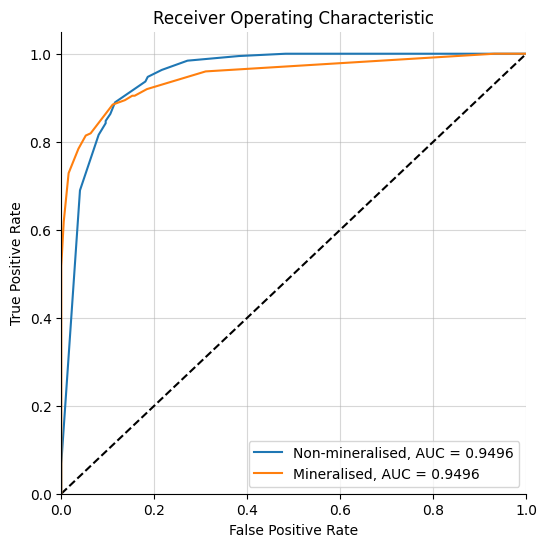

ROC AUC score: 0.949616503570484


In [ ]:
# Generate probability predictions for ROC analysis
labels_prob = model_rf_calibrated.predict_proba(features_rf_test)
labels_name = ["Non-mineralised", "Mineralised"]

# Create ROC plot
roc_plot(labels_rf_test, labels_prob, 2, labels_name)

### Feature Importance (Gini Importance)

Feature importance is a metric used by tree-based models like Random Forests to estimate the relative contribution of each feature to the model's predictions. It is computed by averaging the total reduction in Gini impurity (a measure of node impurity) brought by each feature across all trees in the forest. Features that more frequently and more significantly reduce impurity are considered more important. This helps in understanding which variables have the most influence in the model's decision-making process.

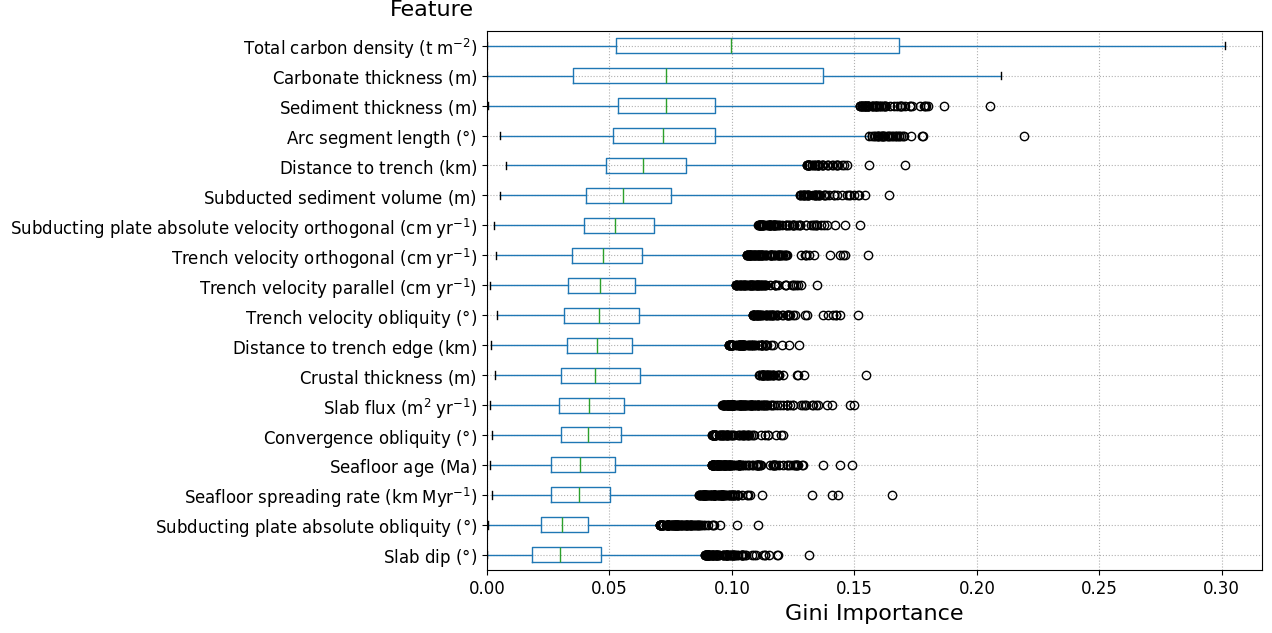

In [ ]:
if os.path.isfile(gini_importances_filename):
    gini_importances = pd.read_csv(gini_importances_filename)   # Load existing Gini importances if available
else:
    # Setup
    n_splits = 5
    n_repeats = 10
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42,
    )
    feature_names = features_rf_test.columns
    gini_importances_all = []

    # Cross-validate with the best estimator
    for idx, _ in cv.split(features_rf, labels_rf):
        features_fold = features_rf.iloc[idx]
        weights_fold = features_fold["weight"]
        features_fold = features_fold.drop("weight", axis=1)
        labels_fold = labels_rf.iloc[idx]

        # Clone and fit
        clf = clone(model_rf_calibrated.estimator)
        clf.fit(features_fold, labels_fold, sample_weight=weights_fold)

        # Extract per-tree importances
        tree_importances = pd.DataFrame(
            [tree.feature_importances_ for tree in clf.estimators_],
            columns=feature_names
        )
        gini_importances_all.append(tree_importances)

    # Combine all results into one DataFrame
    gini_importances = pd.concat(gini_importances_all, ignore_index=True)

    # Sort columns by median importance
    gini_importances = gini_importances[gini_importances.median().sort_values(ascending=False).index]

    # Save to CSV
    gini_importances.to_csv(gini_importances_filename, index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Reverse column order so the most important is on top
gini_importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)

# Customize plot
ax.grid(linestyle="dotted")
ax.set_xlim(0)
ax.set_xlabel("Gini Importance", fontsize=16)
ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=16)
ax.yaxis.set_label_coords(-0.017, 1.02)

# Format y-tick labels
ax.set_yticks(
    ax.get_yticks(),
    [format_feature_name(label.get_text()) for label in ax.get_yticklabels()]
)

# Style tick labels
ax.tick_params(labelsize=12)

plt.show()

### Permutation Importance

Permutation importance is a model-agnostic technique used to evaluate the impact of each feature on a model's predictive performance. It works by randomly shuffling the values of a single feature in the test data and measuring how much the model's performance decreases. If permuting a feature's values significantly degrades the model's score (e.g., F1), it indicates that the feature is important. This method provides a more direct and reliable assessment of feature relevance than internal metrics like Gini importance, especially in the presence of feature interactions or correlations.

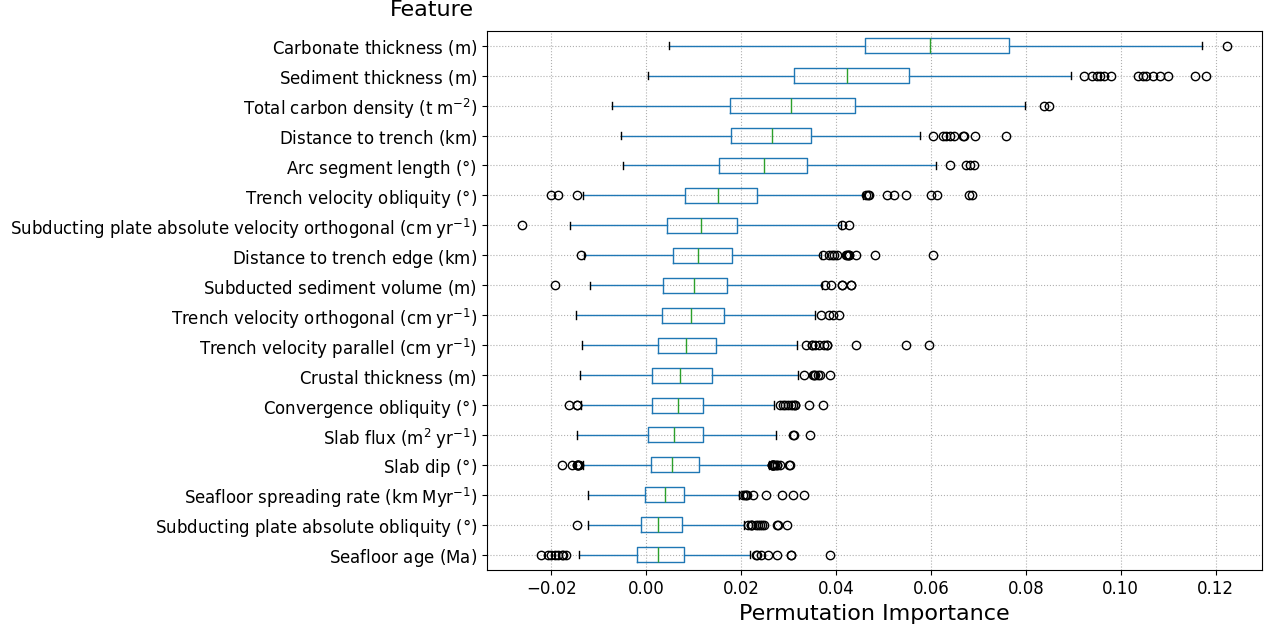

In [ ]:
if os.path.isfile(permutation_importances_filename):
    permutation_importances = pd.read_csv(permutation_importances_filename) # Load existing permutation importances if available
else:
    # Setup
    n_splits = 5
    n_repeats = 10
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42,
    )
    feature_names = features_rf_test.columns
    permutation_importances_all = []

    # Cross-validate with the best estimator
    for train_idx, test_idx in cv.split(features_rf, labels_rf):
        features_train = features_rf.iloc[train_idx]
        weights_train = features_train["weight"]
        features_train = features_train.drop("weight", axis=1)
        labels_train = labels_rf.iloc[train_idx]
        features_test = features_rf.iloc[test_idx]
        weights_test = features_test["weight"]
        features_test = features_test.drop("weight", axis=1)
        labels_test = labels_rf.iloc[test_idx]

        # Clone and fit
        clf = clone(model_rf_calibrated.estimator)
        clf.fit(features_train, labels_train, sample_weight=weights_train)

        result = permutation_importance(clf, features_test, labels_test, sample_weight=weights_test, scoring="f1", n_repeats=10, random_state=42, n_jobs=nprocs)
        result_df = pd.DataFrame(result.importances.T, columns=feature_names)
        permutation_importances_all.append(result_df)

    # Combine all results into one DataFrame
    permutation_importances = pd.concat(permutation_importances_all, ignore_index=True)

    # Sort columns by median importance
    permutation_importances = permutation_importances[permutation_importances.median().sort_values(ascending=False).index]

    # Save to CSV
    permutation_importances.to_csv(permutation_importances_filename, index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Reverse column order so the most important is on top
permutation_importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)

# Customize plot
ax.grid(linestyle="dotted")
ax.set_xlabel("Permutation Importance", fontsize=16)
ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=16)
ax.yaxis.set_label_coords(-0.017, 1.02)

# Format y-tick labels
ax.set_yticks(
    ax.get_yticks(),
    [format_feature_name(label.get_text()) for label in ax.get_yticklabels()]
)

# Style tick labels
ax.tick_params(labelsize=12)

plt.show()

### Partial Dependence and Individual Conditional Expectation

Partial Dependence Plots (PDP) show how individual geological features affect the model's predictions while averaging over all other features. This is useful in revealing trends about particular features for mineralization. Individual Conditional Expectation (ICE) curves show how predictions change for individual samples. This is useful for spotting unusual behavior at particular zones. These plots show how changing one geological feature affects deposit probability, while holding others constant.

It's interactive and lets you select any input feature and explore how it influences model predictions, both on average (PDP) and for specific points in the dataset (ICE curves).

In [ ]:
# Prepare data for PDP/ICE analysis
features_rf_train = Xy_rf_train.copy()
labels_rf_train = features_rf_train["label"]    # Binary: deposit present (1) or absent (0)
weights_rf_train = features_rf_train["weight"]
features_rf_train = features_rf_train.drop(["weight", "label"], axis=1)
feature_names = features_rf_train.columns

# Load scaler to convert back to original geological units
robust_scaler = joblib.load(robust_scaler_filename)
features_rf_train_original_values = features_rf_train * robust_scaler.scale_ + robust_scaler.center_

@interact
def show_pdp_ice(feature=feature_names):
    plt.figure(figsize=(8, 6))

    # Focus on the main data range (5th to 95th percentile) to avoid extreme outliers
    # that might represent measurement errors or very rare geological conditions
    feature_min = features_rf_train_original_values[feature].quantile(0.05)
    feature_max = features_rf_train_original_values[feature].quantile(0.95)
    
    # Generate partial dependence and ICE plots using the calibrated model
    display = PartialDependenceDisplay.from_estimator(
        estimator=model_rf_calibrated.estimator,
        X=features_rf_train,
        features=[feature],
        sample_weight=weights_rf_train,
        # grid_resolution=100,
        kind="both",  # 'both' shows PDP and ICE
        subsample=500,
        n_jobs=nprocs,
        random_state=42,
    )

    # Adjust x-axis limits to focus on the main geological range
    ax = plt.gca()
    x_min, x_max = ax.get_xlim()
    x_ticks = ax.get_xticks()
    mask = (x_ticks >= x_min) & (x_ticks <= x_max)
    x_ticks = x_ticks[mask]
    ax.set_xticks(x_ticks)
    
    # Convert x-ticks back to original geological units
    original_tick_values = feature_min + (x_ticks - x_min) * (feature_max - feature_min) / (x_max - x_min)
    original_tick_labels = [f"{val:.2f}" for val in original_tick_values]
    ax.set_xticklabels(original_tick_labels)

    ax.set_xlabel(f"{format_feature_name(feature)}")

    handles, labels = ax.get_legend_handles_labels()
    new_labels = ['Average' if label == 'average' else label for label in labels]
    
    # Add a title and clear legend
    plt.title(f"Partial Dependence and ICE for '{format_feature_name(feature)}'")
    plt.legend(handles, new_labels, loc='upper right')
    plt.show()

interactive(children=(Dropdown(description='feature', options=('arc_segment_length (degrees)', 'carbonate_thic…

### SHAP Values

SHAP (SHapley Additive exPlanations) values provide a unified measure of feature importance by quantifying how much each feature contributes to a specific prediction. Based on cooperative game theory, SHAP values fairly distribute the difference between a model's prediction and the average prediction among all input features. Unlike methods that only give global importance, SHAP values offer both global and local interpretability, showing not just which features are important, but also how they influence individual predictions—positively or negatively.

The cross-validation approach ensures robust SHAP values that generalize across different geological terrains and time periods. In the visualisation, each point represents one location; position shows SHAP value (contribution to prediction). The color shows feature value (red=high, blue=low, based on the geological parameter values).

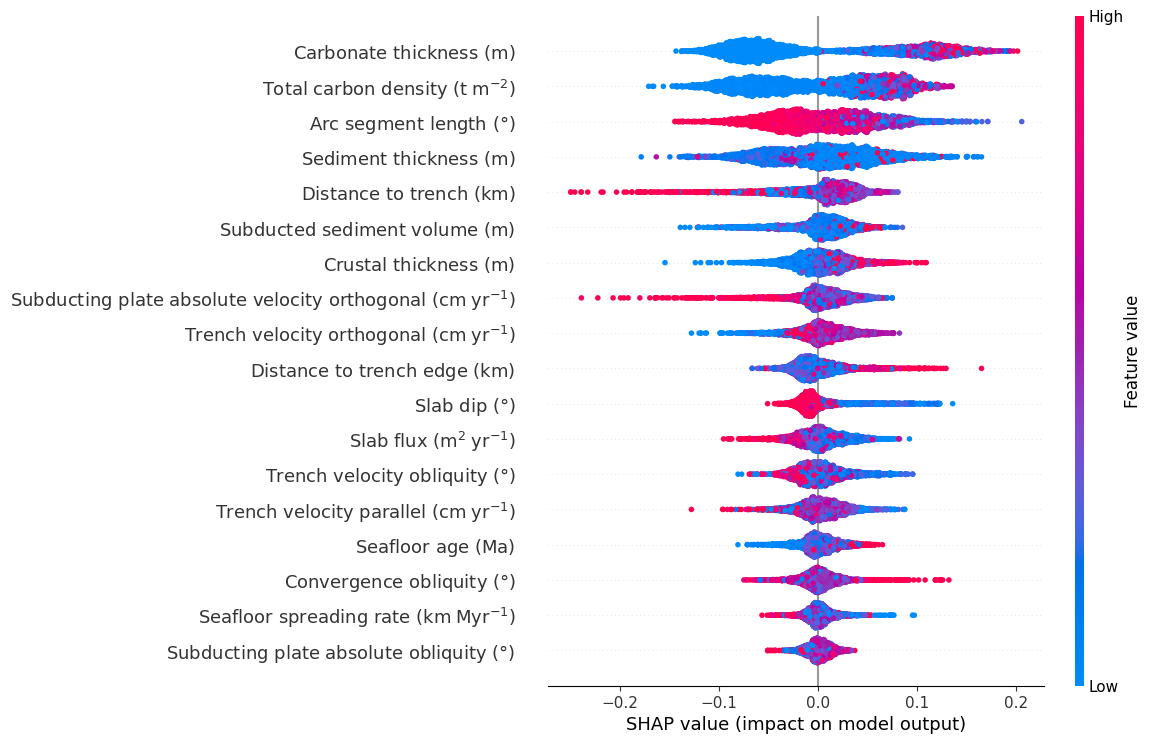

In [ ]:
if os.path.isfile(shap_values_filename):
    # Load existing SHAP values and features if available
    shap_values = pd.read_csv(shap_values_filename)
    shap_values_array = shap_values.values
    features_shap_test = pd.read_csv(features_shap_test_filename)
    feature_names = features_rf_test.columns
else:
    # Setup
    n_splits = 5    # Number of splits for cross-validation
    n_repeats = 2   # Number of times to repeat the cross-validation
    total_folds = n_splits * n_repeats
    
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42,
    )
    
    test_idx_all = []
    shap_values_all = []

    # Cross-validate with the best estimator
    for train_idx, test_idx in tqdm(cv.split(features_rf, labels_rf), total=total_folds, desc="Computing SHAP"):
        # Extract & prepare training and test data for this fold
        features_train = features_rf.iloc[train_idx]
        weights_train = features_train["weight"]
        features_train = features_train.drop("weight", axis=1)
        labels_train = labels_rf.iloc[train_idx]
        
        features_test = features_rf.iloc[test_idx]
        weights_test = features_test["weight"]
        features_test = features_test.drop("weight", axis=1)
        labels_test = labels_rf.iloc[test_idx]
        test_idx_all.extend(test_idx)

        # Clone and fit
        clf = clone(model_rf)
        clf.fit(features_train, labels_train, sample_weight=weights_train)

        # Compute SHAP values on the test set
        # Background data represents the "baseline" geological conditions
        explainer = shap.TreeExplainer(clf, features_train)  # Use training data as background
        result = explainer(features_test, check_additivity=False)
        shap_values_all.append(result)
    
    # Combine all SHAP values from all folds
    shap_values_array = np.vstack([sv.values[:, :, 1] for sv in shap_values_all])
    feature_names = features_rf_test.columns
    shap_values = pd.DataFrame(shap_values_array, columns=feature_names)

    # Save SHAP values and features for future use
    shap_values.to_csv(shap_values_filename, index=False)
    features_shap_test = features_rf.iloc[test_idx_all].drop("weight", axis=1)
    features_shap_test.to_csv(features_shap_test_filename, index=False)

feature_names = [format_feature_name(name) for name in feature_names]

# Create a SHAP explanation object for visualization
explanation = shap.Explanation(
    values=shap_values_array,
    data=features_shap_test.values,
    feature_names=feature_names
)

# Plot SHAP values using a beeswarm plot
shap.plots.beeswarm(explanation, max_display=20)

### Calculate Probability, Entropy, and Vote Variance

This section applies the trained model to the entire seafloor to estimate:
- Probability: Model confidence that geological conditions favor deposit formation
- Entropy: Measure of prediction uncertainty (high entropy implies that the model is uncertain)
- Vote variance: Variability among decision trees (high variance implies conflicting results between samples)

These predictions are saved as global maps (grids), showing where mineralization is most likely and where the model is more or less confident. This enables visualization of how deposit probability varies. This is useful for identifying exploration targets and areas of uncertainty in the predictions.

In [ ]:
if os.path.isfile(target_prob_filename):    # Check if probabilities have already been calculated
    print(f"Probabilities have already been calculated and saved in {target_prob_filename}")
else:
    # Define columns needed for spatial and temporal reference
    columns = [
        "lon",
        "lat",
        "present_lon",
        "present_lat",
        "age (Ma)",
    ]

    # Load target data for prediction
    target_data_dd = dd.read_csv(target_data_filename)
    target_data_out = target_data_dd[columns].compute()
    
    # Get the same features used in model training
    selected_features = model_rf_calibrated.feature_names_in_
    
    # Load and scale target data using the same scaler as training
    target_data = pd.read_csv(target_data_filename)
    target_data_scaled = target_data[selected_features]
    target_data_scaled = robust_scaler.transform(target_data_scaled)
    target_data_scaled = pd.DataFrame(target_data_scaled, columns=selected_features)
    target_data_scaled[columns_to_drop_target] = target_data[columns_to_drop_target]
    
    model_rf_parallel = ParallelPostFit(model_rf_calibrated)

    # Generate predictions for all targets
    target_features = target_data_scaled[selected_features]
    probs = model_rf_parallel.predict_proba(target_features)[:, 1].ravel()  # Probability of deposit
    
    # Combine probabilities with spatial/temporal coordinates
    target_prob = target_data_out.copy()
    target_prob["probability"] = probs
    
    # Entropy quantifies uncertainty in model predictions
    entropies = calculate_entropy(probs) 
    target_prob["entropy"] = entropies
    
    # Vote variance shows disagreement among decision trees
    vote_variances = calculate_tree_vote_variance(model_rf_calibrated.estimator, target_features.values)
    target_prob["vote_variance"] = vote_variances
    
    del probs
    target_prob.to_csv(target_prob_filename, index=False)
    del target_prob

if os.path.exists(prob_grids_dir):  # Check if probability grids already exist
    print(f"Probability grids are located in {prob_grids_dir}")
else:
    os.makedirs(prob_grids_dir, exist_ok=True)
    os.makedirs(entropy_grids_dir, exist_ok=True)
    os.makedirs(vote_variance_grids_dir, exist_ok=True)

    # Create probability, entropy, and vote variance grids
    create_grids(
        data=target_prob_filename,
        output_dir=prob_grids_dir,
        extent=(-180, 180, -90, 90),    # Global extent
        threads=nprocs,
        verbose=True,
        column="probability",
        filename_format="probability_grid_{}Ma.nc",        
    )
    
    create_grids(
        data=target_prob_filename,
        output_dir=entropy_grids_dir,
        extent=(-180, 180, -90, 90),
        threads=nprocs,
        verbose=True,
        column="entropy",
        filename_format="entropy_grid_{}Ma.nc",        
    )

    create_grids(
        data=target_prob_filename,
        output_dir=vote_variance_grids_dir,
        extent=(-180, 180, -90, 90),
        threads=nprocs,
        verbose=True,
        column="vote_variance",
        filename_format="vote_variance_grid_{}Ma.nc",        
    )

Probabilities have already been calculated and saved in outputs\ml\target_prob.csv
Probability grids are located in outputs\ml\prob_grids


### Probability Maps

This section creates an interactive probability map showing deposit probability overlaid on reconstructed paleo-geography at a selected time. This visualization reveals spatial patterns (how deposit probability relates to tectonic features) & temporal evolution (how favorable conditions migrate through time).

The map displays:
- Probability grid: Colors show deposit formation likelihood
- Plate boundaries: Tectonic framework (ridges, transforms, subduction zones)
- Seafloor age: Background showing crustal age provinces
- Known deposits: Actual deposit locations for validation

The maps use plate tectonic reconstructions to show ancient geographic positions, essential for understanding deposit formation in their original geological context. This tool is useful for manually exploring how mineralization changes over time.

In [ ]:
# Load plate tectonic reconstruction model
plate_model, _tf = get_plate_reconstruction(
    model_name=plate_model_name,
    model_dir=plate_model_dir,
    filter_topologies=True,  # Remove invalid/uncertain plate boundaries
)

# Get plot topologies for visualization
gplot = get_plot_topologies(
    model_name=plate_model_name,
    model_dir=plate_model_dir,
    plate_reconstruction=plate_model,
    filter_topologies=True,
)

# Set up the map projection (Mollweide) and central meridian
projection = ccrs.Mollweide(central_longitude=60)
central_meridian = 0

In [ ]:
@interact
def show_map(time=time_steps):
    gplot.time = time  # Set reconstruction time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            prob_grids_dir,
            f"probability_grid_{time:0.0f}Ma.nc",
        ),  # Deposit probability grid
        grid_type="probability",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),  # Seafloor age for geological context
        positives=deposit_recon_coords_all_filename,  # Known deposit locations
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

This workflow generates a complete sequence of deposit probability maps through geological time and compiles them into a time-lapse animation.

Each map shows the spatial distribution of mineral prospectivity at a given time slice, reconstructed on a paleo-geographic surface with seafloor age as geological context. The sequence of maps captures how the modelled probability of deposit presence evolves over time.

In [ ]:
# Generate all probability maps and create animation
if os.path.exists(prob_maps_dir):
    print(f"Probability maps are located in {prob_maps_dir}")
else:
    os.makedirs(prob_maps_dir, exist_ok=True)

    # Create maps in parallel for efficiency
    with Parallel(
        n_jobs=nprocs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // nprocs) + 1,
    ) as parallel:

        # Define output filenames for each time step
        output_filenames = [
            os.path.join(prob_maps_dir, f"probability_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot)(
                gplot=gplot,
                grid=os.path.join(
                    prob_grids_dir,
                    f"probability_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="probability",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_recon_coords_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create geological time animation showing evolution of deposit probability
    # Animation reveals temporal patterns in geological processes
    output_filename = os.path.join(ml_dir, "probability_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],  # Reverse chronological order (old to young)
        output_filename=output_filename,
        fps=10,  # Frame rate for smooth geological time progression
        bitrate="5000k",
    )

Probability maps are located in outputs\ml\prob_maps


### Entropy Maps

Entropy is a statistical measure of uncertainty in the model’s probability predictions.

- Low entropy (near 0): The model is confident. Its predictions strongly lean toward either high or low likelihood of deposits.

- High entropy (near 1): The model is uncertain. It assigns probabilities close to 50%, meaning it’s unsure whether the conditions favor or disfavor deposit formation.

Entropy maps let you explore spatial uncertainty in mineralization through geological time. By sliding through different time steps, you can visualise entropy maps, which highlight regions where the model's predictions are most and least certain. 

The visualization combines several key geological datasets: entropy grids that show geological complexity patterns, seafloor age maps that reveal the history of ocean floor spreading, and reconstructed positions of mineral deposits as they existed millions of years ago. This code segment generates an interactive graph that displays an entropy map for a selected geological time, allowing users to explore spatial uncertainty in mineral prospectivity through time.

In [ ]:
@interact
def show_map(time=time_steps):
    gplot.time = time   # Set reconstruction time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            entropy_grids_dir,
            f"entropy_grid_{time:0.0f}Ma.nc",
        ),  # Entropy grid for uncertainty visualization
        grid_type="entropy",    # Specify entropy grid type for visualization
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),  # Seafloor age for geological context
        positives=deposit_recon_coords_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

This workflow automatically generates a series of geological time-slice entropy maps, then compiles them into a visual animation. Each frame shows how uncertainty in the model shifts across space and time, with deposit locations reconstructed into their paleo-positions for context. The time-lapse animation provides a clear way to communicate model uncertainty across geological history

It is ideal for understanding when and where predictive models are most stable or variable.

In [1]:
# Generate all entropy maps and create animation
if os.path.exists(entropy_maps_dir):
    print(f"Entropy maps are located in {entropy_maps_dir}")
else:
    os.makedirs(entropy_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=nprocs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // nprocs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(entropy_maps_dir, f"entropy_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot)(
                gplot=gplot,
                grid=os.path.join(
                    entropy_grids_dir,
                    f"entropy_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="entropy",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_recon_coords_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "entropy_animation.mp4")     # Output animation filename
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

NameError: name 'os' is not defined

### Vote Variance Maps

Vote variance maps illustrate model disagreement i.e. showing where different iterations of the predictive model give varying answers about where mineralization is likely to occur. It works by having each tree in the random forest cast a "vote" for a given location’s geological features, predicting either the presence or absence of a deposit (or a probability). The vote variance is then calculated as the statistical variance of these votes across all trees in the forest. 

High vote variance indicates less agreement between models, suggesting uncertainty in the geological features driving mineralization or data inputs for that region. Low variance, on the other hand, points to model consensus and more stable predictive signals.

This code segment generates an interactive graph that displays a vote variance map for a selected geological time, allowing users to explore model agreement or disagreement in predicted mineral prospectivity through time.

In [ ]:
@interact
def show_map(time=time_steps):
    gplot.time = time   # Set reconstruction time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            vote_variance_grids_dir,
            f"vote_variance_grid_{time:0.0f}Ma.nc",
        ),  # Vote variance grid for model uncertainty
        grid_type="vote variance",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),  # Seafloor age for geological context
        positives=deposit_recon_coords_all_filename,    # Known deposit locations
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

This workflow generates a full temporal sequence of vote variance maps, then stitches them into a high-quality animation that spans geological time. Each frame highlights where model consensus about mineralization is strong or weak at a given time slice.

The result is a clear visualisation of how exploration confidence evolves over time. It provides both spatial and temporal context for where predictive models align (or disagree) on the presence of mineralization.

In [ ]:
# Generate all vote variance maps and create animation
if os.path.exists(vote_variance_maps_dir):
    print(f"Vote variance maps are located in {vote_variance_maps_dir}")
else:
    os.makedirs(vote_variance_maps_dir, exist_ok=True)


    with Parallel(
        n_jobs=nprocs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // nprocs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(vote_variance_maps_dir, f"vote_variance_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot)(
                gplot=gplot,
                grid=os.path.join(
                    vote_variance_grids_dir,
                    f"vote_variance_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="vote variance",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_recon_coords_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "vote_variance_animation.mp4")   # Output animation filename
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Vote variance maps are located in outputs\ml\vote_variance_maps
